In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import numpy as np
import math
from IPython.display import display, clear_output

# --- Environment Setup ---
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
print(f"Available GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current GPU name: {torch.cuda.get_device_name(0)}")

# Check for Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {DEVICE}")

Available GPUs: 1
Current GPU name: NVIDIA GeForce RTX 5090
Using Device: cuda


In [31]:
# --- Hyperparameters ---
WEIGHT_DECAY = 0.1     
LR = 1e-3              
BATCH_SIZE = 1000      # Full batch training for stability
TRAIN_SIZE = 1000      # Small dataset to allow memorization
TEST_SIZE = 200
DIGITS = 3             # 3-digit addition (e.g., 123+456)
MAX_EPOCHS = 80000     # Give it enough time to train

# Model Config (Mini-GPT)
N_EMBD = 128
N_HEAD = 4
N_LAYER = 2
VOCAB = "0123456789+=<" # < is the End-of-Sequence token
VOCAB_SIZE = len(VOCAB)

In [32]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # The following lines ensure reproducibility for convolutional layers
    # This is for teaching/demo purposes; in practice, the first four lines are usually sufficient
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False
    print(f"Random Seed set to: {seed}")

set_seed(9876) 

print(f"Available GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current GPU name: {torch.cuda.get_device_name(0)}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {DEVICE}")

Random Seed set to: 9876
Available GPUs: 1
Current GPU name: NVIDIA GeForce RTX 5090
Using Device: cuda


In [33]:
# --- Data Generation Function ---
def generate_dataset_lines(num_samples):
    lines = []
    seen = set()
    while len(lines) < num_samples:
        a = random.randint(0, 10**DIGITS - 1)
        b = random.randint(0, 10**DIGITS - 1)
        c = a + b
        
        # Reverse strings for better learning logic
        # 123 -> 321
        a_s = str(a).zfill(DIGITS)[::-1]
        b_s = str(b).zfill(DIGITS)[::-1]
        c_s = str(c).zfill(DIGITS + 1)[::-1]
        
        # Format: "321+654=9750<"
        full_str = f"{a_s}+{b_s}={c_s}<"
        
        if full_str not in seen:
            seen.add(full_str)
            lines.append(full_str)
    return lines

# --- Export to File ---
# Define the path based on user request
data_path = "../../data/minigpt_input.txt"

# Ensure directory exists
os.makedirs(os.path.dirname(data_path), exist_ok=True)

# Generate data
total_samples = TRAIN_SIZE + TEST_SIZE
raw_data_lines = generate_dataset_lines(total_samples)

# Write to disk
with open(data_path, "w", encoding="utf-8") as f:
    for line in raw_data_lines:
        f.write(line + "\n")

print(f"Successfully generated {len(raw_data_lines)} samples.")
print(f"Data saved to: {os.path.abspath(data_path)}")

Successfully generated 1200 samples.
Data saved to: /home/leiyo/GitHub/Applied-Machine-Learning-Course/data/minigpt_input.txt


In [34]:
# --- Tokenizer Setup ---
STO_I = {s: i for i, s in enumerate(VOCAB)}
ITO_S = {i: s for i, s in enumerate(VOCAB)}

def encode(s): return [STO_I[c] for c in s]
def decode(ids): return "".join([ITO_S[i] for i in ids])

# --- Load Data from File ---
data_path = "../../data/minigpt_input.txt"

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found at {data_path}. Please run Cell 2 first.")

print(f"Loading data from: {data_path} ...")

with open(data_path, "r", encoding="utf-8") as f:
    loaded_lines = f.read().splitlines()

# Split into Train/Test
train_texts = loaded_lines[:TRAIN_SIZE]
test_texts = loaded_lines[TRAIN_SIZE:]

# Create Tensors
train_tensors = [torch.tensor(encode(s), dtype=torch.long) for s in train_texts]
test_tensors = [torch.tensor(encode(s), dtype=torch.long) for s in test_texts]

print(f"Total Training Samples: {len(train_texts)}")
print(f"Total Test Samples: {len(test_texts)}")
print("-" * 30)
print("Example of Raw Data (What the AI actually sees):")
# print(f"Human View: 123 + 456 = 579")
# print(f"AI View:    {train_texts[0]}")
# print("(Note: The digits are REVERSED to help the AI learn carries)")

Loading data from: ../../data/minigpt_input.txt ...
Total Training Samples: 1000
Total Test Samples: 200
------------------------------
Example of Raw Data (What the AI actually sees):


In [35]:
# --- Transformer Components ---
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        assert n_embd % n_head == 0
        self.c_attn = nn.Linear(n_embd, 3 * n_embd)
        self.c_proj = nn.Linear(n_embd, n_embd)
        self.n_head = n_head
        self.n_embd = n_embd
        self.register_buffer("bias", torch.tril(torch.ones(block_size, block_size))
                                     .view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

class MLP(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.c_fc    = nn.Linear(n_embd, 4 * n_embd)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * n_embd, n_embd)
    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = MLP(n_embd)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.block_size = 32 # Context length
        self.token_embedding = nn.Embedding(VOCAB_SIZE, N_EMBD)
        self.position_embedding = nn.Embedding(self.block_size, N_EMBD)
        self.blocks = nn.Sequential(*[Block(N_EMBD, N_HEAD, self.block_size) for _ in range(N_LAYER)])
        self.ln_f = nn.LayerNorm(N_EMBD)
        self.head = nn.Linear(N_EMBD, VOCAB_SIZE, bias=False)

    def forward(self, idx):
        B, T = idx.shape
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(pos)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits
        
print("Model Architecture Defined.")

Model Architecture Defined.


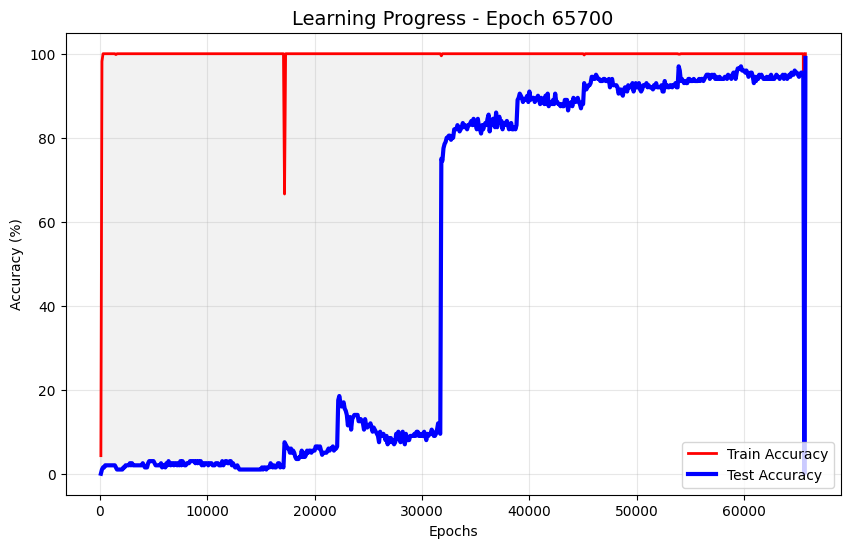

Epoch 65700: Train=100.0% | Test=99.0%

[SUCCESS] Grokking achieved at Epoch 65700!


In [36]:
# --- Evaluation Helper ---
def evaluate(model, dataset_tensors):
    model.eval()
    correct = 0
    total = len(dataset_tensors)
    
    # Process in one full batch for speed
    inputs = torch.stack(dataset_tensors).to(DEVICE)
    
    # Logic to split "Prompt" vs "Answer"
    # Prompt: "321+654=" (len = 3+1+3+1 = 8)
    prompt_len = DIGITS + 1 + DIGITS + 1 
    # Target: "9750<" (len = 3+1+1 = 5)
    target_len = DIGITS + 1 + 1 
    
    with torch.no_grad():
        curr_input = inputs[:, :prompt_len]
        
        # Autoregressive generation (token by token)
        for _ in range(target_len):
            logits = model(curr_input)
            next_token_ids = logits[:, -1, :].argmax(dim=1).unsqueeze(1)
            curr_input = torch.cat([curr_input, next_token_ids], dim=1)
            
        generated = curr_input[:, prompt_len:]
        targets = inputs[:, prompt_len:]
        
        matches = (generated == targets).all(dim=1)
        correct = matches.sum().item()
        
    return correct / total

# --- Initialization ---
model = MiniGPT().to(DEVICE)
# AdamW is crucial. It applies the Weight Decay.
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

print(f"Model initialized on {DEVICE}")
print("Ready to train!")

# --- Training Loop with Live Plot ---
train_acc_history = []
test_acc_history = []
epochs_list = []

# Prepare data on GPU
full_train_batch = torch.stack(train_tensors).to(DEVICE)
train_inputs = full_train_batch[:, :-1]
train_targets = full_train_batch[:, 1:]

fig, ax = plt.subplots(figsize=(10, 6))

print("Starting Training... Watch the plot update!")
print("Look for the moment when the Blue Line (Test) suddenly jumps up.")

try:
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        
        optimizer.zero_grad()
        logits = model(train_inputs)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), train_targets.reshape(-1))
        loss.backward()
        
        # Gradient Clipping helps stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        # Update Plot every 100 epochs
        if epoch % 100 == 0:
            train_acc = evaluate(model, train_tensors)
            test_acc = evaluate(model, test_tensors)
            
            epochs_list.append(epoch)
            train_acc_history.append(train_acc * 100)
            test_acc_history.append(test_acc * 100)
            
            # Live Plotting Logic
            clear_output(wait=True)
            ax.clear()
            ax.plot(epochs_list, train_acc_history, 'r-', label='Train Accuracy', linewidth=2)
            ax.plot(epochs_list, test_acc_history, 'b-', label='Test Accuracy', linewidth=3)
            
            ax.set_title(f"Learning Progress - Epoch {epoch}", fontsize=14)
            ax.set_xlabel("Epochs")
            ax.set_ylabel("Accuracy (%)")
            ax.set_ylim(-5, 105)
            ax.legend(loc='lower right')
            ax.grid(True, alpha=0.3)
            ax.fill_between(epochs_list, train_acc_history, test_acc_history, color='gray', alpha=0.1)
            
            display(fig)
            print(f"Epoch {epoch}: Train={train_acc*100:.1f}% | Test={test_acc*100:.1f}%")
            
            # Early stop if converged
            if test_acc > 0.98:
                print(f"\n[SUCCESS] Grokking achieved at Epoch {epoch}!")
                break
                
except KeyboardInterrupt:
    print("\nTraining stopped manually.")
finally:
    plt.close()

In [37]:
def predict_user_input(model, user_input):
    """
    Takes a string like "123+456", reverses it for the model,
    predicts the answer, and reverses it back for the human.
    """
    model.eval()
    
    # 1. Parsing & Preprocessing (Reverse inputs)
    try:
        if "=" not in user_input:
            user_input += "="
        parts = user_input.split("+")
        a = parts[0].strip()
        b = parts[1].replace("=", "").strip()
        
        # Reverse format: 123 -> 321
        a_rev = a.zfill(DIGITS)[::-1]
        b_rev = b.zfill(DIGITS)[::-1]
        
        # Prompt: "321+654="
        model_input_str = f"{a_rev}+{b_rev}="
        print(f"Internal Model Input (Reversed): {model_input_str}")
        
    except Exception as e:
        print("Error: Please format input as '123+456'")
        return

    # 2. Model Inference
    input_ids = torch.tensor([encode(model_input_str)], dtype=torch.long).to(DEVICE)
    
    with torch.no_grad():
        curr_input = input_ids
        # Generate until '<' or max length
        max_new_tokens = DIGITS + 2 
        
        generated_ids = []
        for _ in range(max_new_tokens):
            logits = model(curr_input)
            next_token_id = logits[0, -1, :].argmax().item()
            next_char = ITO_S[next_token_id]
            
            if next_char == '<': # End token
                break
                
            generated_ids.append(next_token_id)
            curr_input = torch.cat([curr_input, torch.tensor([[next_token_id]], device=DEVICE)], dim=1)
            
    # 3. Post-processing (Reverse back)
    # Model output might be "9750" (which is 0579 reversed)
    raw_output = decode(generated_ids)
    final_answer = raw_output[::-1]
    
    print("-" * 30)
    print(f"Problem: {user_input}")
    # print(f"Model Raw Output (Reversed): {raw_output}")
    try:
        print(f"Final Decoded Answer: {int(final_answer)}") # int() removes leading zeros
    except ValueError:
        print(f"Final Decoded Answer (Raw): {final_answer} (Could not parse to int)")
    print("-" * 30)

In [39]:
# --- USER INPUT AREA ---
# Change this string to test different numbers!
prompt = "777+777=" 
predict_user_input(model, prompt)

Internal Model Input (Reversed): 777+777=
------------------------------
Problem: 777+777=
Final Decoded Answer: 1554
------------------------------
